In [2]:
# Load necessary library
library(fs)
library("ggplot2")
install.packages("tidyverse")
library(dplyr)
library("tidyverse")
# Required library for rolling mean
library(zoo)  # Install if needed: install.packages("zoo")
# Assuming 'dot_plot_data' is wide format, create a heatmap (for a grid of values)

library(RColorBrewer)


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



load fixed r files

In [31]:
filepath_newhetfile_smbc_full_chr <- paste0("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/Maesot_out/mut_rate_4.0425e-09/top4/")

plot_data_list_newhetfile_smbc_full_chr_fixed_r <- list()

for (i in 9:14) {
    chr <- sprintf("%02d", i)
    

    file_pattern <- paste0("Maesot_chr", chr, "_top4_individuals_region_.*\\.mhs\\.rds$")
    
    matching_files <- list.files(filepath_newhetfile_smbc_full_chr, pattern = file_pattern, full.names = TRUE)
    
    if (length(matching_files) > 0) {
        maesot_smbc_fixed_r <- readRDS(matching_files[1])
        plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]] <- maesot_smbc_fixed_r
        cat("Loaded chr", chr, ":", basename(matching_files[1]), "\n")
    } else {
        cat("No files found for chr", chr, "in", filepath_newhetfile_smbc_full_chr, "\n")
    }
}


Loaded chr 09 : Maesot_chr09_top4_individuals_region_79101-1195286,1202254-1242137,1244484-1473560.mhs.rds 
Loaded chr 10 : Maesot_chr10_top4_individuals_region_68971-1393947,1394389-1571815.mhs.rds 
Loaded chr 11 : Maesot_chr11_top4_individuals_region_110001-831968,834246-1986017,1986793-2003320.mhs.rds 
Loaded chr 12 : Maesot_chr12_top4_individuals_region_60301-766654,780451-1282773,1285068-1688600,1745531-2163700.mhs.rds 
Loaded chr 13 : Maesot_chr13_top4_individuals_region_74414-1168127,1170426-2791900.mhs.rds 
Loaded chr 14 : Maesot_chr14_top4_individuals_region_35775-1071523,1075090-3255710.mhs.rds 


load full chromosome data

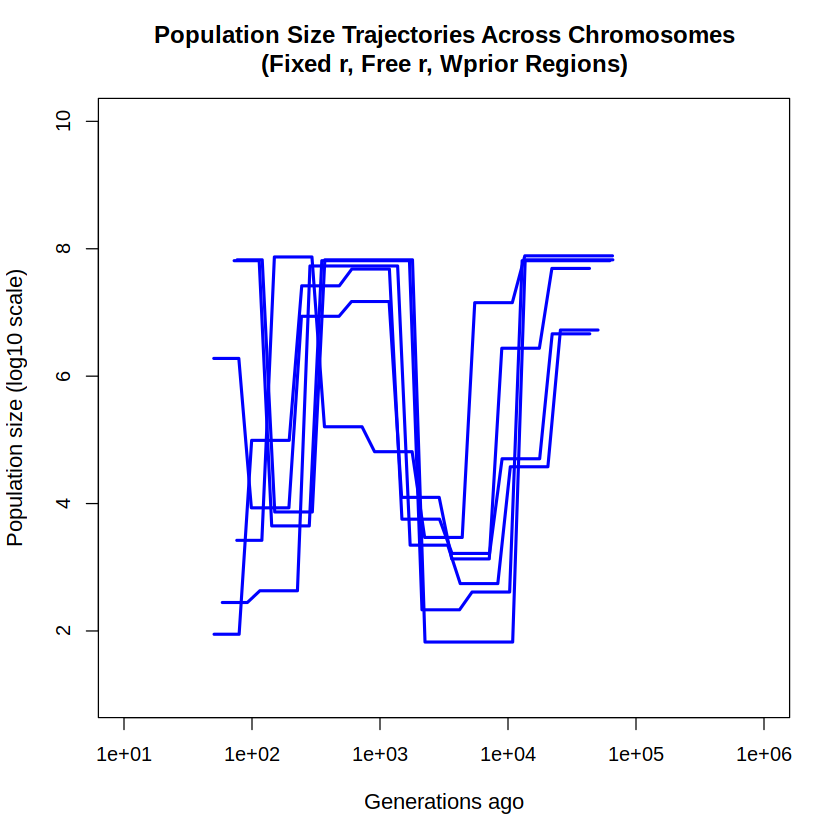

In [ ]:
# Set mutation rate and generation time
mu <- 4.0425e-09
gen <- 0.16

par(bg = "white", mfrow = c(1, 1))  # Clean plot setup

# Set up main plot with proper limits and labels
plot(c(10, 10^6), c(1, 10), 
     log = "x", type = "n", 
     xlab = "Generations ago", 
     ylab = "Population size (log10 scale)", 
     main = "Population Size Trajectories Across Chromosomes\n(Fixed r, Regions)",
     cex.lab = 1.1, cex.main = 1.2)




# 2. Plot main thick lines for full chromosomes (from your fixed_r list + others)
main_chrs <- names(plot_data_list_newhetfile_smbc_full_chr_fixed_r)
for (chr in main_chrs) {
  # Fixed r full chr (red thick line)
  if (!is.null(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]])) {
    data <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]
    Tc <- data$Tc * gen
    Ne_t <- data$Xi
    Ne_scale <- mean(data$mu / mu)
    lines(Tc * Ne_scale, log10(Ne_t * Ne_scale), 
          col = 'blue', lwd = plot_types$fixed_r_fullchr$lwd)
  }
  
  # Add other data types here when available (free_r_fullchr, wprior_fullchr)
  # Follow same pattern with their respective data lists
}




In [ ]:
plot_data_list_newhetfile_smbc_full_chr_fixed_r

In [44]:
# Initialize empty vectors for alpha and rho/mu values
rho_values <- c()
alpha_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()  # To store valid chromosome names
category_labels <- c()  # To store categories (e.g., Free_r Regions, Free_r Full)

for (chr in names(plot_data_list_newhetfile_smbc_full_chr_fixed_r)) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            # Append data to the vectors

            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)  # Add chromosome name
            category_labels <- c(category_labels, rep("Fixed r subset Regions", length(chr_data$rho)))
        }
    }
}


# Create a data frame for plotting
boxplot_data <- data.frame(
    chromosomes=chromosomes,
    Rho = rho_values,
    Alpha = alpha_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Category = category_labels
)

boxplot_data


chromosomes,Rho,Alpha,Rho_Mu_Ratio,Category
<chr>,<dbl>,<dbl>,<dbl>,<chr>
09,0.002708401,1.15,10,Fixed r subset Regions
10,0.003128798,1.50,10,Fixed r subset Regions
11,0.002624147,1.20,10,Fixed r subset Regions
12,0.001954260,1.35,10,Fixed r subset Regions
13,0.001984841,1.40,10,Fixed r subset Regions
14,0.002169281,1.25,10,Fixed r subset Regions


In [43]:
unique(boxplot_data$Category)


boxplot_data$Category <- as.character(boxplot_data$Category)


[1] "Fixed r Core Regions"